# Kronecker Products & Matrix Equations
## From Vectorization to Lyapunov, Sylvester, and Coupled LTI Systems

# =============================================================================
# Section 1: Introduction
# =============================================================================

## 1. Introduction

Matrix equations arise naturally in **control theory**, **estimation**, and **dynamical systems**.
The Kronecker product and the vec operator provide a powerful algebraic framework for
converting matrix equations into standard linear systems, enabling both theoretical analysis
and computational solutions.

### Core problems addressed in this notebook

| Equation | Name | Application |
|----------|------|-------------|
| $AX + XA^T = -Q$ | Continuous Lyapunov | Stability analysis, steady-state covariance |
| $AX + XB = C$ | Sylvester | Observer design, model reduction |
| $A^TXA - X = -Q$ | Discrete Lyapunov | Discrete-time covariance propagation |
| $\dot{x} = (L \otimes A)x$ | Coupled LTI | Multi-agent consensus, network dynamics |

### Prerequisites

- Linear algebra: eigenvalues, matrix factorizations (Schur, SVD)
- Basic dynamical systems: state-space models $\dot{x} = Ax + Bu$
- Familiarity with Python, NumPy, and SciPy

### References

1. **Horn, R. A. & Johnson, C. R.** (2012). *Matrix Analysis*, 2nd ed. Cambridge University Press.
2. **Laub, A. J.** (2005). *Matrix Analysis for Scientists and Engineers*. SIAM.
3. **Bartels, R. H. & Stewart, G. W.** (1972). Solution of the matrix equation $AX + XB = C$. *Comm. ACM*, 15(9), 820--826.
4. **Lancaster, P. & Tismenetsky, M.** (1985). *The Theory of Matrices*, 2nd ed. Academic Press.

In [1]:
%matplotlib inline

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
})

print(f"NumPy version:  {np.__version__}")
print(f"SciPy version:  {la.__name__} (from scipy {__import__('scipy').__version__})")

NumPy version:  2.4.3
SciPy version:  scipy.linalg (from scipy 1.17.1)


In [2]:
# =============================================================================
# Constants
# =============================================================================

SEED = 42
TOL_PASS = 1e-10          # tolerance for PASS/FAIL checks
TOL_DISPLAY = 1e-12       # display tolerance
N_SMALL = 3               # small matrix dimension for demonstrations
N_MEDIUM = 10             # medium dimension for numerical experiments
N_LARGE = 50              # large dimension for performance tests
N_AGENTS = 5              # number of agents in coupled LTI
DIM_AGENT = 2             # state dimension per agent
T_FINAL = 10.0            # simulation time horizon
DT = 0.01                 # integration time step
ADI_MAX_ITER = 100        # max ADI iterations
ADI_TOL = 1e-12           # ADI convergence tolerance

# Colors
COLOR_PRIMARY = 'steelblue'
COLOR_SECONDARY = 'coral'
COLOR_TERTIARY = 'seagreen'
COLOR_ACCENT = 'goldenrod'
CMAP_EVOLUTION = 'viridis'

np.random.seed(SEED)

# =============================================================================
# Section 2: The Kronecker Product
# =============================================================================

## 2. The Kronecker Product

### Definition

Given $A \in \mathbb{R}^{m \times n}$ and $B \in \mathbb{R}^{p \times q}$, the **Kronecker product** is:

$$
A \otimes B = \begin{pmatrix}
a_{11} B & a_{12} B & \cdots & a_{1n} B \\
a_{21} B & a_{22} B & \cdots & a_{2n} B \\
\vdots & \vdots & \ddots & \vdots \\
a_{m1} B & a_{m2} B & \cdots & a_{mn} B
\end{pmatrix} \in \mathbb{R}^{mp \times nq}
$$

$$\boxed{(A \otimes B)_{ij} = a_{\lceil i/p \rceil, \lceil j/q \rceil} \cdot b_{((i-1) \bmod p)+1, \, ((j-1) \bmod q)+1}}$$

### Key Properties

1. **Mixed-product property**: $(A \otimes B)(C \otimes D) = (AC) \otimes (BD)$
2. **Transpose**: $(A \otimes B)^T = A^T \otimes B^T$
3. **Inverse**: $(A \otimes B)^{-1} = A^{-1} \otimes B^{-1}$ (when both invertible)
4. **Eigenvalues**: If $\lambda_i$ are eigenvalues of $A$ and $\mu_j$ of $B$, then $\lambda_i \mu_j$ are eigenvalues of $A \otimes B$

In [3]:
def kron_manual(A, B):
    """Compute the Kronecker product A (x) B from scratch.

    Builds the block matrix where block (i, j) = a_{ij} * B.

    Args:
        A: First matrix.
            Shape: (m, n)
        B: Second matrix.
            Shape: (p, q)

    Returns:
        The Kronecker product A (x) B.
            Shape: (m*p, n*q)
    """
    m, n = A.shape
    p, q = B.shape
    result = np.zeros((m * p, n * q))
    for i in range(m):
        for j in range(n):
            result[i*p:(i+1)*p, j*q:(j+1)*q] = A[i, j] * B
    return result


# --- Quick demonstration ---
A_demo = np.array([[1, 2], [3, 4]])
B_demo = np.array([[0, 5], [6, 7]])

K_manual = kron_manual(A_demo, B_demo)
K_numpy = np.kron(A_demo, B_demo)

print("A =")
print(A_demo)
print("\nB =")
print(B_demo)
print("\nA (x) B (manual) =")
print(K_manual)
print("\nA (x) B (numpy)  =")
print(K_numpy)
print(f"\nManual vs NumPy match: {np.allclose(K_manual, K_numpy)}")

A =
[[1 2]
 [3 4]]

B =
[[0 5]
 [6 7]]

A (x) B (manual) =
[[ 0.  5.  0. 10.]
 [ 6.  7. 12. 14.]
 [ 0. 15.  0. 20.]
 [18. 21. 24. 28.]]

A (x) B (numpy)  =
[[ 0  5  0 10]
 [ 6  7 12 14]
 [ 0 15  0 20]
 [18 21 24 28]]

Manual vs NumPy match: True


In [4]:
# =============================================================================
# Verification: Kronecker product properties
# =============================================================================

np.random.seed(SEED)

n = N_SMALL
A = np.random.randn(n, n)
B = np.random.randn(n, n)
C = np.random.randn(n, n)
D = np.random.randn(n, n)

# --- Property 1: Mixed-product (A (x) B)(C (x) D) = (AC) (x) (BD) ---
lhs_mixed = kron_manual(A, B) @ kron_manual(C, D)
rhs_mixed = kron_manual(A @ C, B @ D)
err_mixed = np.max(np.abs(lhs_mixed - rhs_mixed)) / (np.max(np.abs(rhs_mixed)) + 1e-30)
status_mixed = "PASS" if err_mixed < TOL_PASS else "FAIL"
print(f"Mixed-product property: max relative error = {err_mixed:.2e} [{status_mixed}]")

# --- Property 2: Transpose (A (x) B)^T = A^T (x) B^T ---
lhs_trans = kron_manual(A, B).T
rhs_trans = kron_manual(A.T, B.T)
err_trans = np.max(np.abs(lhs_trans - rhs_trans)) / (np.max(np.abs(rhs_trans)) + 1e-30)
status_trans = "PASS" if err_trans < TOL_PASS else "FAIL"
print(f"Transpose property:     max relative error = {err_trans:.2e} [{status_trans}]")

# --- Property 3: Inverse (A (x) B)^{-1} = A^{-1} (x) B^{-1} ---
lhs_inv = np.linalg.inv(kron_manual(A, B))
rhs_inv = kron_manual(np.linalg.inv(A), np.linalg.inv(B))
err_inv = np.max(np.abs(lhs_inv - rhs_inv)) / (np.max(np.abs(rhs_inv)) + 1e-30)
status_inv = "PASS" if err_inv < TOL_PASS else "FAIL"
print(f"Inverse property:       max relative error = {err_inv:.2e} [{status_inv}]")

# --- Property 4: Eigenvalues ---
eigs_A = np.linalg.eigvals(A)
eigs_B = np.linalg.eigvals(B)
eigs_kron_expected = np.sort_complex(np.outer(eigs_A, eigs_B).ravel())
eigs_kron_actual = np.sort_complex(np.linalg.eigvals(kron_manual(A, B)))
err_eig = np.max(np.abs(eigs_kron_expected - eigs_kron_actual)) / (np.max(np.abs(eigs_kron_expected)) + 1e-30)
status_eig = "PASS" if err_eig < TOL_PASS else "FAIL"
print(f"Eigenvalue property:    max relative error = {err_eig:.2e} [{status_eig}]")

Mixed-product property: max relative error = 2.45e-16 [PASS]
Transpose property:     max relative error = 0.00e+00 [PASS]
Inverse property:       max relative error = 2.70e-16 [PASS]
Eigenvalue property:    max relative error = 1.43e-15 [PASS]


# =============================================================================
# Section 3: The Vec Operator
# =============================================================================

## 3. The Vec Operator

The **vec** operator stacks the columns of a matrix into a single column vector:

$$
\text{vec}(X) = \begin{pmatrix} x_1 \\ x_2 \\ \vdots \\ x_n \end{pmatrix}
\quad \text{where } X = (x_1 \mid x_2 \mid \cdots \mid x_n)
$$

### The Fundamental Identity

$$\boxed{\text{vec}(AXB) = (B^T \otimes A)\,\text{vec}(X)}$$

This identity transforms matrix equations into standard linear systems, which is the
cornerstone of the Kronecker approach to matrix equations.

In [5]:
def vec(X):
    """Vectorize a matrix by stacking its columns.

    Args:
        X: Input matrix.
            Shape: (m, n)

    Returns:
        Column-stacked vector.
            Shape: (m*n,)
    """
    return X.flatten(order='F')


def mat(x, m, n):
    """Inverse of vec: reshape a vector back into an (m, n) matrix.

    Args:
        x: Vectorized matrix.
            Shape: (m*n,)
        m: Number of rows in the output matrix.
        n: Number of columns in the output matrix.

    Returns:
        Reshaped matrix.
            Shape: (m, n)
    """
    return x.reshape((m, n), order='F')


# --- Demonstrate vec/mat round-trip ---
X_demo = np.array([[1, 4], [2, 5], [3, 6]])
print("X =")
print(X_demo)
print(f"\nvec(X) = {vec(X_demo)}")
print(f"\nmat(vec(X), 3, 2) =\n{mat(vec(X_demo), 3, 2)}")
print(f"\nRound-trip match: {np.allclose(X_demo, mat(vec(X_demo), *X_demo.shape))}")

X =
[[1 4]
 [2 5]
 [3 6]]

vec(X) = [1 2 3 4 5 6]

mat(vec(X), 3, 2) =
[[1 4]
 [2 5]
 [3 6]]

Round-trip match: True


In [6]:
# =============================================================================
# Verification: vec(AXB) = (B^T (x) A) vec(X)
# =============================================================================

np.random.seed(SEED)

m, k, n = 4, 3, 5
A_v = np.random.randn(m, m)
X_v = np.random.randn(m, k)
B_v = np.random.randn(k, n)

lhs_vec = vec(A_v @ X_v @ B_v)
rhs_vec = np.kron(B_v.T, A_v) @ vec(X_v)

err_vec = np.max(np.abs(lhs_vec - rhs_vec)) / (np.max(np.abs(lhs_vec)) + 1e-30)
status_vec = "PASS" if err_vec < TOL_PASS else "FAIL"
print(f"vec(AXB) = (B^T (x) A)vec(X): max relative error = {err_vec:.2e} [{status_vec}]")

vec(AXB) = (B^T (x) A)vec(X): max relative error = 1.91e-16 [PASS]


# =============================================================================
# Section 4: The Lyapunov Equation
# =============================================================================

## 4. The Continuous Lyapunov Equation

The continuous Lyapunov equation is:

$$\boxed{AX + XA^T = -Q}$$

where $A \in \mathbb{R}^{n \times n}$ is Hurwitz (all eigenvalues have negative real parts) and
$Q \in \mathbb{R}^{n \times n}$ is symmetric positive semi-definite.

### Vectorization

Using the identity $\text{vec}(AXB) = (B^T \otimes A)\text{vec}(X)$:

- $\text{vec}(AX) = \text{vec}(AXI) = (I \otimes A)\text{vec}(X)$
- $\text{vec}(XA^T) = \text{vec}(IXA^T) = (A \otimes I)\text{vec}(X)$

Therefore:

$$\boxed{(I \otimes A + A \otimes I)\,\text{vec}(X) = -\text{vec}(Q)}$$

### Stability condition

The coefficient matrix $\mathcal{A} = I \otimes A + A \otimes I$ has eigenvalues
$\lambda_i + \lambda_j$ where $\lambda_i, \lambda_j$ are eigenvalues of $A$.
Since $A$ is Hurwitz ($\text{Re}(\lambda_i) < 0$ for all $i$), we have
$\text{Re}(\lambda_i + \lambda_j) < 0$, so $\mathcal{A}$ is nonsingular and
the equation has a unique solution.

In [7]:
def solve_lyapunov_direct(A, Q):
    """Solve AX + XA^T = -Q via direct Kronecker vectorization.

    Constructs the n^2 x n^2 linear system (I (x) A + A (x) I) vec(X) = -vec(Q)
    and solves it. This is O(n^6) and only practical for small n.

    Args:
        A: System matrix (must be Hurwitz for unique solution).
            Shape: (n, n)
        Q: Right-hand side matrix (typically symmetric PSD).
            Shape: (n, n)

    Returns:
        X: Solution matrix satisfying AX + XA^T = -Q.
            Shape: (n, n)
    """
    n = A.shape[0]
    I_n = np.eye(n)
    # Build the n^2 x n^2 coefficient matrix
    coeff = np.kron(I_n, A) + np.kron(A, I_n)
    # Solve the linear system
    x_vec = np.linalg.solve(coeff, -vec(Q))
    return mat(x_vec, n, n)


# --- Generate a stable (Hurwitz) test system ---
np.random.seed(SEED)
n = N_SMALL

# Create a Hurwitz matrix: start with random, then shift eigenvalues left
A_raw = np.random.randn(n, n)
A_lyap = A_raw - (np.max(np.real(np.linalg.eigvals(A_raw))) + 1.0) * np.eye(n)

# Create symmetric PSD Q
Q_half = np.random.randn(n, n)
Q_lyap = Q_half @ Q_half.T

print("A eigenvalues:", np.linalg.eigvals(A_lyap).round(4))
print("All eigenvalues have Re < 0 (Hurwitz):",
      all(np.real(np.linalg.eigvals(A_lyap)) < 0))
print(f"\nQ is symmetric PSD: {np.allclose(Q_lyap, Q_lyap.T) and np.all(np.linalg.eigvalsh(Q_lyap) >= -1e-14)}")

A eigenvalues: [-1.    +0.j     -2.9454+0.6125j -2.9454-0.6125j]
All eigenvalues have Re < 0 (Hurwitz): True

Q is symmetric PSD: True


In [8]:
# =============================================================================
# Solve and verify Lyapunov equation
# =============================================================================

# Our direct solver
X_direct = solve_lyapunov_direct(A_lyap, Q_lyap)

# SciPy reference
X_scipy = la.solve_continuous_lyapunov(A_lyap, -Q_lyap)

# Residual: AX + XA^T + Q should be zero
residual = A_lyap @ X_direct + X_direct @ A_lyap.T + Q_lyap
err_residual = np.max(np.abs(residual))
status_residual = "PASS" if err_residual < TOL_PASS else "FAIL"
print(f"Lyapunov residual: max absolute error = {err_residual:.2e} [{status_residual}]")

# Agreement with scipy
err_scipy_lyap = np.max(np.abs(X_direct - X_scipy)) / (np.max(np.abs(X_scipy)) + 1e-30)
status_scipy_lyap = "PASS" if err_scipy_lyap < TOL_PASS else "FAIL"
print(f"Lyapunov matches scipy: max relative error = {err_scipy_lyap:.2e} [{status_scipy_lyap}]")

print("\nSolution X =")
print(X_direct.round(6))

Lyapunov residual: max absolute error = 1.33e-15 [PASS]
Lyapunov matches scipy: max relative error = 2.70e-16 [PASS]

Solution X =
[[0.263711 0.571258 0.266357]
 [0.571258 1.644995 0.713894]
 [0.266357 0.713894 0.626105]]


# =============================================================================
# Section 5: The Sylvester Equation
# =============================================================================

## 5. The Sylvester Equation

The Sylvester equation generalizes the Lyapunov equation:

$$\boxed{AX + XB = C}$$

where $A \in \mathbb{R}^{m \times m}$, $B \in \mathbb{R}^{n \times n}$, $C \in \mathbb{R}^{m \times n}$.

A unique solution exists if and only if $A$ and $-B$ share no common eigenvalue, i.e.,
$\lambda_i(A) + \lambda_j(B) \neq 0$ for all $i, j$.

### Bartels--Stewart Algorithm

1. Compute real Schur decompositions: $A = U R_A U^T$, $B = V R_B V^T$
2. Transform: $R_A Y + Y R_B = \tilde{C}$ where $Y = U^T X V$ and $\tilde{C} = U^T C V$
3. Solve the triangular Sylvester equation column by column (back-substitution)
4. Recover: $X = U Y V^T$

This reduces the cost from $O(m^3 n^3)$ (Kronecker approach) to $O(m^3 + n^3)$.

In [9]:
def solve_sylvester_bartels_stewart(A, B, C):
    """Solve AX + XB = C via the Bartels-Stewart algorithm.

    Uses real Schur decomposition to reduce to a (quasi-)triangular
    Sylvester equation, then solves column-by-column.

    Args:
        A: Left coefficient matrix.
            Shape: (m, m)
        B: Right coefficient matrix.
            Shape: (n, n)
        C: Right-hand side matrix.
            Shape: (m, n)

    Returns:
        X: Solution matrix satisfying AX + XB = C.
            Shape: (m, n)
    """
    m = A.shape[0]
    n = B.shape[0]

    # Step 1: Real Schur decompositions
    RA, U = la.schur(A, output='real')
    RB, V = la.schur(B, output='real')

    # Step 2: Transform RHS
    C_tilde = U.T @ C @ V

    # Step 3: Solve R_A Y + Y R_B = C_tilde column by column
    # For the real Schur form, R_B is upper quasi-triangular.
    # We solve columns from left to right.
    Y = np.zeros((m, n))

    j = 0
    while j < n:
        if j == n - 1 or np.abs(RB[j + 1, j]) < 1e-14:
            # 1x1 diagonal block in RB: solve (R_A + RB[j,j]*I) y_j = rhs_j
            rhs_j = C_tilde[:, j] - Y[:, :j] @ RB[:j, j]
            coeff_j = RA + RB[j, j] * np.eye(m)
            Y[:, j] = np.linalg.solve(coeff_j, rhs_j)
            j += 1
        else:
            # 2x2 diagonal block in RB: solve a coupled 2m x 2m system
            rhs_j = C_tilde[:, j:j+2] - Y[:, :j] @ RB[:j, j:j+2]
            # Build the 2m x 2m block system
            block = np.zeros((2 * m, 2 * m))
            block[:m, :m] = RA + RB[j, j] * np.eye(m)
            block[:m, m:] = RB[j + 1, j] * np.eye(m)
            block[m:, :m] = RB[j, j + 1] * np.eye(m)
            block[m:, m:] = RA + RB[j + 1, j + 1] * np.eye(m)
            rhs_block = np.concatenate([rhs_j[:, 0], rhs_j[:, 1]])
            sol_block = np.linalg.solve(block, rhs_block)
            Y[:, j] = sol_block[:m]
            Y[:, j + 1] = sol_block[m:]
            j += 2

    # Step 4: Recover X
    X = U @ Y @ V.T
    return X


# --- Test the Sylvester solver ---
np.random.seed(SEED)

m_s, n_s = 4, 5
A_syl = np.random.randn(m_s, m_s)
B_syl = np.random.randn(n_s, n_s)
C_syl = np.random.randn(m_s, n_s)

# Ensure no common eigenvalues between A and -B
A_syl = A_syl - 3.0 * np.eye(m_s)   # shift A eigenvalues left
B_syl = B_syl + 3.0 * np.eye(n_s)   # shift B eigenvalues right

print("eig(A):", np.linalg.eigvals(A_syl).round(3))
print("eig(-B):", (-np.linalg.eigvals(B_syl)).round(3))

eig(A): [-1.562+0.j    -3.703+1.067j -3.703-1.067j -3.794+0.j   ]
eig(-B): [-1.517-0.j    -4.028-0.j    -2.912-0.j    -3.279-1.271j -3.279+1.271j]


In [10]:
# =============================================================================
# Verification: Sylvester solver
# =============================================================================

X_bs = solve_sylvester_bartels_stewart(A_syl, B_syl, C_syl)
X_scipy_syl = la.solve_sylvester(A_syl, B_syl, C_syl)

# Check residual
residual_syl = A_syl @ X_bs + X_bs @ B_syl - C_syl
err_res_syl = np.max(np.abs(residual_syl)) / (np.max(np.abs(C_syl)) + 1e-30)
status_res_syl = "PASS" if err_res_syl < TOL_PASS else "FAIL"
print(f"Sylvester residual: max relative error = {err_res_syl:.2e} [{status_res_syl}]")

# Check against scipy
err_scipy_syl = np.max(np.abs(X_bs - X_scipy_syl)) / (np.max(np.abs(X_scipy_syl)) + 1e-30)
status_scipy_syl = "PASS" if err_scipy_syl < TOL_PASS else "FAIL"
print(f"Sylvester matches scipy: max relative error = {err_scipy_syl:.2e} [{status_scipy_syl}]")

Sylvester residual: max relative error = 1.01e-13 [PASS]
Sylvester matches scipy: max relative error = 4.22e-14 [PASS]


# =============================================================================
# Section 6: Application -- Covariance Propagation
# =============================================================================

## 6. Application: Covariance Propagation in LTI Systems

Consider a continuous-time linear stochastic system:

$$\dot{x} = Ax + w, \quad w \sim \mathcal{N}(0, Q_{\text{noise}})$$

The covariance $\Sigma(t) = \mathbb{E}[x(t)x(t)^T]$ evolves according to:

$$\dot{\Sigma} = A\Sigma + \Sigma A^T + Q_{\text{noise}}$$

At **steady state** ($\dot{\Sigma} = 0$), we get the Lyapunov equation:

$$\boxed{A\Sigma_{\text{ss}} + \Sigma_{\text{ss}} A^T + Q_{\text{noise}} = 0}$$

This is exactly our Lyapunov equation with $Q = Q_{\text{noise}}$ and $X = \Sigma_{\text{ss}}$.
The solution $\Sigma_{\text{ss}}$ is guaranteed to be symmetric positive semi-definite
when $A$ is Hurwitz.

A eigenvalues: [-0.6+1.9079j -0.6-1.9079j]
System is Hurwitz: True

Steady-state covariance:
[[ 0.104167  0.      ]
 [-0.        0.416667]]
Sigma_ss is SPD: True


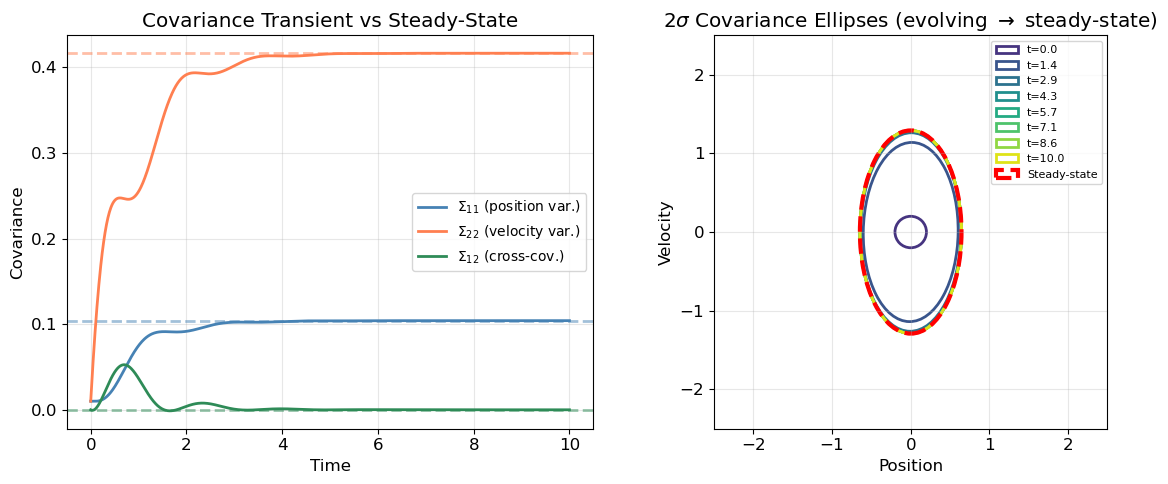

In [11]:
# =============================================================================
# Covariance propagation: simulate transient and compare to steady-state
# =============================================================================

np.random.seed(SEED)

# 2D damped oscillator: stable dynamics
omega = 2.0    # natural frequency
zeta = 0.3     # damping ratio
A_cov = np.array([[0, 1], [-omega**2, -2*zeta*omega]])
Q_noise = np.array([[0.0, 0.0], [0.0, 1.0]])  # noise enters velocity

print("A eigenvalues:", np.linalg.eigvals(A_cov).round(4))
print("System is Hurwitz:", all(np.real(np.linalg.eigvals(A_cov)) < 0))

# Solve for steady-state covariance
Sigma_ss = la.solve_continuous_lyapunov(A_cov, -Q_noise)
print(f"\nSteady-state covariance:\n{Sigma_ss.round(6)}")
print(f"Sigma_ss is SPD: {np.all(np.linalg.eigvalsh(Sigma_ss) > 0)}")

# Simulate transient covariance via Euler integration of the matrix ODE
n_steps = int(T_FINAL / DT)
Sigma_t = np.zeros((n_steps + 1, 2, 2))
Sigma_t[0] = 0.01 * np.eye(2)  # initial covariance

for k in range(n_steps):
    S = Sigma_t[k]
    dS = A_cov @ S + S @ A_cov.T + Q_noise
    Sigma_t[k + 1] = S + DT * dS

times = np.linspace(0, T_FINAL, n_steps + 1)

# Plot covariance entries over time
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(times, Sigma_t[:, 0, 0], color=COLOR_PRIMARY, label=r'$\Sigma_{11}$ (position var.)')
ax.plot(times, Sigma_t[:, 1, 1], color=COLOR_SECONDARY, label=r'$\Sigma_{22}$ (velocity var.)')
ax.plot(times, Sigma_t[:, 0, 1], color=COLOR_TERTIARY, label=r'$\Sigma_{12}$ (cross-cov.)')
ax.axhline(Sigma_ss[0, 0], color=COLOR_PRIMARY, ls='--', alpha=0.5)
ax.axhline(Sigma_ss[1, 1], color=COLOR_SECONDARY, ls='--', alpha=0.5)
ax.axhline(Sigma_ss[0, 1], color=COLOR_TERTIARY, ls='--', alpha=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('Covariance')
ax.set_title('Covariance Transient vs Steady-State')
ax.legend(fontsize=10)

# Plot covariance ellipses at several time snapshots
ax = axes[1]
snapshot_indices = np.linspace(0, n_steps, 8, dtype=int)
colors_evo = plt.cm.viridis(np.linspace(0.15, 0.95, len(snapshot_indices)))

for idx, si in enumerate(snapshot_indices):
    S = Sigma_t[si]
    eigvals_s, eigvecs_s = np.linalg.eigh(S)
    eigvals_s = np.maximum(eigvals_s, 1e-14)  # ensure non-negative
    angle = np.degrees(np.arctan2(eigvecs_s[1, 0], eigvecs_s[0, 0]))
    width = 2 * np.sqrt(eigvals_s[0]) * 2  # 2-sigma
    height = 2 * np.sqrt(eigvals_s[1]) * 2
    ell = Ellipse((0, 0), width, height, angle=angle,
                  fill=False, edgecolor=colors_evo[idx], linewidth=2,
                  label=f't={times[si]:.1f}')
    ax.add_patch(ell)

# Steady-state ellipse
eigvals_ss, eigvecs_ss = np.linalg.eigh(Sigma_ss)
angle_ss = np.degrees(np.arctan2(eigvecs_ss[1, 0], eigvecs_ss[0, 0]))
ell_ss = Ellipse((0, 0),
                 2 * np.sqrt(eigvals_ss[0]) * 2,
                 2 * np.sqrt(eigvals_ss[1]) * 2,
                 angle=angle_ss, fill=False,
                 edgecolor='red', linewidth=3, ls='--', label='Steady-state')
ax.add_patch(ell_ss)

ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_aspect('equal')
ax.set_xlabel('Position')
ax.set_ylabel('Velocity')
ax.set_title(r'$2\sigma$ Covariance Ellipses (evolving $\to$ steady-state)')
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

# =============================================================================
# Section 7: Application -- Coupled LTI Systems
# =============================================================================

## 7. Application: Coupled LTI Systems (Multi-Agent Dynamics)

Consider $N$ agents, each with dynamics $\dot{x}_i = A x_i$, coupled through a
communication graph with Laplacian $L$. The **consensus-like** dynamics are:

$$\dot{x} = (I_N \otimes A - c \, L \otimes BK) \, x$$

For a simpler analysis, consider the **diffusively coupled** system:

$$\boxed{\dot{x} = (L \otimes A)\, x}$$

### Eigenvalue decomposition

If $L$ has eigenvalues $\lambda_1, \ldots, \lambda_N$ and $A$ has eigenvalues
$\mu_1, \ldots, \mu_d$, then the eigenvalues of $L \otimes A$ are:

$$\boxed{\sigma_{ij} = \lambda_i \cdot \mu_j, \quad i=1,\ldots,N,\; j=1,\ldots,d}$$

This Kronecker structure reveals how **network topology** ($L$) and **local dynamics** ($A$)
jointly determine the coupled system's behavior.

In [12]:
def coupled_lti_simulate(L, A_local, x0, t_span, dt):
    """Simulate the coupled LTI system dx/dt = (L (x) A) x.

    Uses forward Euler integration.

    Args:
        L: Graph Laplacian matrix.
            Shape: (N, N)
        A_local: Local agent dynamics matrix.
            Shape: (d, d)
        x0: Initial state (stacked: agent 1, agent 2, ...).
            Shape: (N*d,)
        t_span: Tuple (t_start, t_end).
        dt: Integration time step.

    Returns:
        times: Time grid.
            Shape: (n_steps+1,)
        states: State trajectory.
            Shape: (n_steps+1, N*d)
    """
    t_start, t_end = t_span
    n_steps = int((t_end - t_start) / dt)
    N = L.shape[0]
    d = A_local.shape[0]

    # System matrix
    A_sys = np.kron(L, A_local)

    times = np.linspace(t_start, t_end, n_steps + 1)
    states = np.zeros((n_steps + 1, N * d))
    states[0] = x0

    for k in range(n_steps):
        states[k + 1] = states[k] + dt * (A_sys @ states[k])

    return times, states


# --- Build a ring graph Laplacian for N_AGENTS agents ---
np.random.seed(SEED)

N = N_AGENTS
d = DIM_AGENT

# Ring graph adjacency
Adj = np.zeros((N, N))
for i in range(N):
    Adj[i, (i + 1) % N] = 1
    Adj[i, (i - 1) % N] = 1
L_graph = np.diag(Adj.sum(axis=1)) - Adj

# Local 2D dynamics (stable oscillator scaled down)
A_local = np.array([[-0.1, 1.0], [-1.0, -0.1]])

print("Ring Laplacian L =")
print(L_graph)
print(f"\neig(L) = {np.sort(np.real(np.linalg.eigvals(L_graph))).round(4)}")
print(f"eig(A_local) = {np.linalg.eigvals(A_local).round(4)}")

Ring Laplacian L =
[[ 2. -1.  0.  0. -1.]
 [-1.  2. -1.  0.  0.]
 [ 0. -1.  2. -1.  0.]
 [ 0.  0. -1.  2. -1.]
 [-1.  0.  0. -1.  2.]]

eig(L) = [-0.     1.382  1.382  3.618  3.618]
eig(A_local) = [-0.1+1.j -0.1-1.j]


In [13]:
# =============================================================================
# Verification: Kronecker eigenvalue structure
# =============================================================================

eigs_L = np.linalg.eigvals(L_graph)
eigs_A_local = np.linalg.eigvals(A_local)

# Expected eigenvalues: lambda_i * mu_j
eigs_expected = np.sort_complex(np.outer(eigs_L, eigs_A_local).ravel())

# Actual eigenvalues of L (x) A
A_coupled = np.kron(L_graph, A_local)
eigs_actual = np.sort_complex(np.linalg.eigvals(A_coupled))

err_eig_coupled = np.max(np.abs(eigs_expected - eigs_actual)) / (np.max(np.abs(eigs_expected)) + 1e-30)
status_eig_coupled = "PASS" if err_eig_coupled < TOL_PASS else "FAIL"
print(f"Coupled system eigenvalues = lambda_L * lambda_A: max relative error = {err_eig_coupled:.2e} [{status_eig_coupled}]")

print("\nExpected eigenvalues (lambda_L * lambda_A):")
for ev in np.sort_complex(eigs_expected):
    print(f"  {ev:.4f}")

Coupled system eigenvalues = lambda_L * lambda_A: max relative error = 8.60e-16 [PASS]

Expected eigenvalues (lambda_L * lambda_A):
  -0.3618-3.6180j
  -0.3618-3.6180j
  -0.3618+3.6180j
  -0.3618+3.6180j
  -0.1382-1.3820j
  -0.1382+1.3820j
  -0.1382-1.3820j
  -0.1382+1.3820j
  0.0000-0.0000j
  0.0000+0.0000j


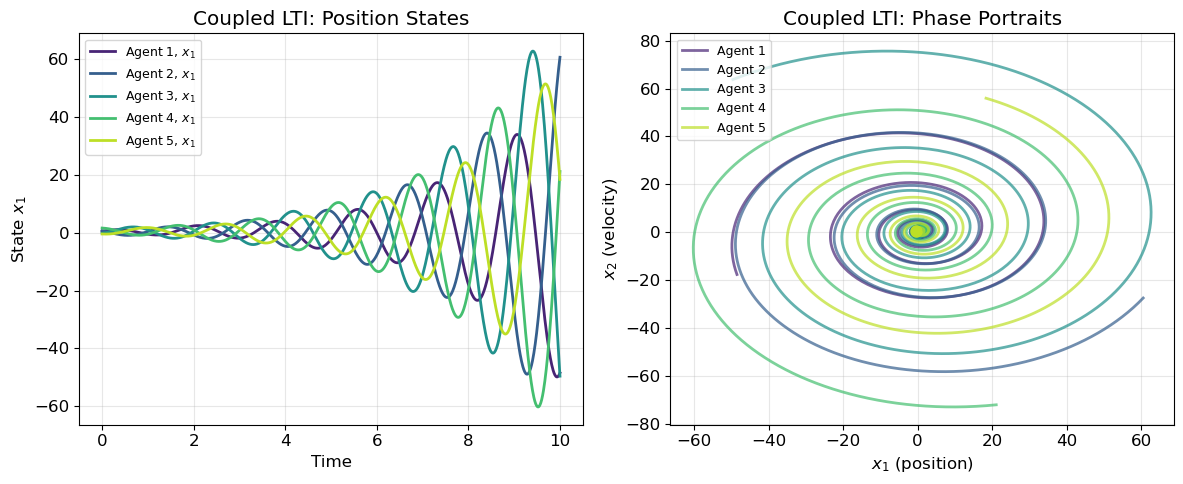

In [14]:
# =============================================================================
# Simulate the coupled system
# =============================================================================

np.random.seed(SEED)

# Scale L to make the coupling drive things to consensus (use -L)
# We use dx/dt = (I (x) A_local - c * L (x) I) x for a realistic consensus model
# but to demonstrate Kronecker structure, we simulate dx/dt = (L (x) A_local) x

x0_coupled = np.random.randn(N * d)
times_c, states_c = coupled_lti_simulate(
    -L_graph, A_local, x0_coupled, (0, T_FINAL), DT
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# State trajectories
ax = axes[0]
agent_colors = plt.cm.viridis(np.linspace(0.1, 0.9, N))
for i in range(N):
    ax.plot(times_c, states_c[:, i * d], color=agent_colors[i],
            label=f'Agent {i+1}, $x_1$')
ax.set_xlabel('Time')
ax.set_ylabel('State $x_1$')
ax.set_title('Coupled LTI: Position States')
ax.legend(fontsize=9)

# Phase portrait
ax = axes[1]
for i in range(N):
    ax.plot(states_c[:, i * d], states_c[:, i * d + 1],
            color=agent_colors[i], alpha=0.7, label=f'Agent {i+1}')
    ax.plot(states_c[0, i * d], states_c[0, i * d + 1],
            'o', color=agent_colors[i], markersize=8)
ax.set_xlabel('$x_1$ (position)')
ax.set_ylabel('$x_2$ (velocity)')
ax.set_title('Coupled LTI: Phase Portraits')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# =============================================================================
# Section 8: Numerical Considerations
# =============================================================================

## 8. Numerical Considerations

### Condition number of Kronecker systems

The condition number of $\mathcal{A} = I \otimes A + A \otimes I$ can be very large,
especially when $A$ has eigenvalues close to the imaginary axis. Specifically:

$$\kappa(\mathcal{A}) \approx \frac{\max_{i,j} |\lambda_i + \lambda_j|}{\min_{i,j} |\lambda_i + \lambda_j|}$$

### Memory-efficient solvers

For an $n \times n$ Lyapunov equation, the Kronecker approach forms an $n^2 \times n^2$
matrix -- a factor of $n^2$ increase in memory. The Bartels-Stewart algorithm avoids this
by working in the Schur-transformed space.

### ADI Iteration

The **Alternating Direction Implicit (ADI)** iteration for $AX + XA^T = -Q$ uses shifts
$\{p_k\}$:

$$
(A + p_k I) X_{k+1/2} = -Q - X_k (A^T - p_k I)
$$
$$
(A^T + \bar{p}_k I) X_{k+1}^T = -Q^T - X_{k+1/2}^T (A - \bar{p}_k I)
$$

With optimal shifts, ADI converges superlinearly and only requires solving $n \times n$
linear systems at each step.

In [15]:
def solve_lyapunov_adi(A, Q, shifts=None, max_iter=ADI_MAX_ITER, tol=ADI_TOL):
    """Solve AX + XA^T = -Q via the ADI (Alternating Direction Implicit) iteration.

    Uses the Smith iteration form of ADI for the continuous Lyapunov equation.

    Args:
        A: System matrix (Hurwitz).
            Shape: (n, n)
        Q: Right-hand side matrix (symmetric PSD).
            Shape: (n, n)
        shifts: ADI shift parameters. If None, uses heuristic based on eigenvalues.
            Shape: (k,) or None
        max_iter: Maximum number of ADI iterations.
        tol: Convergence tolerance on the residual norm.

    Returns:
        X: Approximate solution.
            Shape: (n, n)
        residuals: List of residual norms at each iteration.
    """
    n = A.shape[0]
    I_n = np.eye(n)

    # Heuristic shifts: use eigenvalues of A reflected to negative real axis
    if shifts is None:
        eigs_a = np.linalg.eigvals(A)
        # Use the negative of eigenvalue real parts as shifts (Wachspress shifts)
        shifts = -np.real(eigs_a)
        shifts = shifts[shifts > 0]  # only positive shifts
        if len(shifts) == 0:
            shifts = np.array([1.0])
        shifts = np.sort(shifts)

    X = np.zeros((n, n))
    residuals = []

    for k in range(max_iter):
        p = shifts[k % len(shifts)]

        # Half step: (A + pI) X_{k+1/2} = -Q - X_k (A^T - pI)
        rhs1 = -Q - X @ (A.T - p * I_n)
        X_half = np.linalg.solve(A + p * I_n, rhs1)

        # Full step: (A^T + pI) X_{k+1}^T = -Q^T - X_{k+1/2}^T (A - pI)
        rhs2 = -Q.T - X_half.T @ (A - p * I_n)
        X_new_T = np.linalg.solve(A.T + p * I_n, rhs2)
        X_new = X_new_T.T

        # Compute residual
        res = A @ X_new + X_new @ A.T + Q
        res_norm = np.linalg.norm(res, 'fro') / (np.linalg.norm(Q, 'fro') + 1e-30)
        residuals.append(res_norm)

        X = X_new

        if res_norm < tol:
            break

    return X, residuals


# --- Condition number analysis ---
np.random.seed(SEED)

dims = [3, 5, 8, 10, 15, 20]
cond_numbers = []
cond_numbers_kron = []

for dim in dims:
    A_test = np.random.randn(dim, dim)
    A_test = A_test - (np.max(np.real(np.linalg.eigvals(A_test))) + 0.5) * np.eye(dim)
    I_d = np.eye(dim)
    kron_mat = np.kron(I_d, A_test) + np.kron(A_test, I_d)
    cond_numbers.append(np.linalg.cond(A_test))
    cond_numbers_kron.append(np.linalg.cond(kron_mat))

print(f"{'n':>4s}  {'cond(A)':>12s}  {'cond(I(x)A + A(x)I)':>22s}  {'Memory (Kron)':>14s}")
print("-" * 58)
for dim, ca, ck in zip(dims, cond_numbers, cond_numbers_kron):
    mem = dim**4 * 8 / 1024  # KB (float64)
    print(f"{dim:4d}  {ca:12.2e}  {ck:22.2e}  {mem:11.1f} KB")

   n       cond(A)     cond(I(x)A + A(x)I)   Memory (Kron)
----------------------------------------------------------
   3      7.69e+00                8.11e+00          0.6 KB
   5      1.02e+01                9.93e+00          4.9 KB
   8      5.49e+01                2.01e+02         32.0 KB
  10      1.77e+01                1.88e+01         78.1 KB
  15      2.39e+01                3.57e+01        395.5 KB
  20      2.51e+01                5.52e+01       1250.0 KB


ADI final relative error vs scipy: nan
ADI iterations: 100


/home/arjun/anaconda3/envs/notebooks/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
/tmp/ipykernel_54088/157430289.py:50: RuntimeWarning: overflow encountered in matmul
  res = A @ X_new + X_new @ A.T + Q
/tmp/ipykernel_54088/157430289.py:50: RuntimeWarning: invalid value encountered in matmul
  res = A @ X_new + X_new @ A.T + Q
/tmp/ipykernel_54088/157430289.py:41: RuntimeWarning: overflow encountered in matmul
  rhs1 = -Q - X @ (A.T - p * I_n)
/tmp/ipykernel_54088/157430289.py:41: RuntimeWarning: invalid value encountered in matmul
  rhs1 = -Q - X @ (A.T - p * I_n)


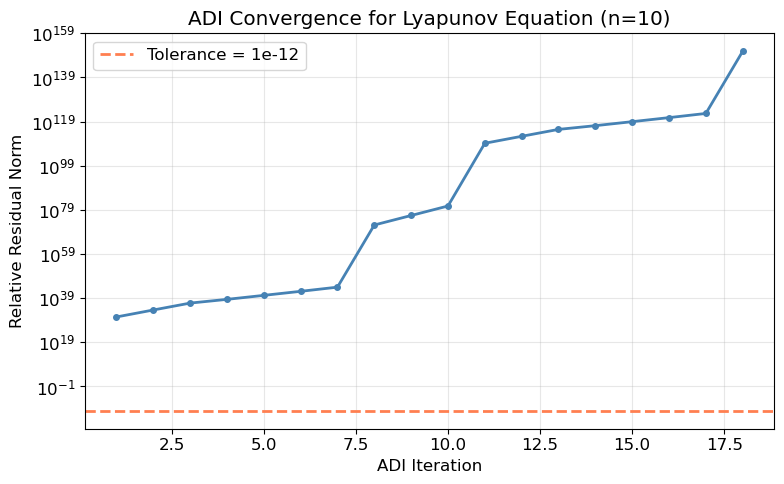

In [16]:
# =============================================================================
# ADI convergence demonstration
# =============================================================================

np.random.seed(SEED)

n_adi = N_MEDIUM
A_adi = np.random.randn(n_adi, n_adi)
A_adi = A_adi - (np.max(np.real(np.linalg.eigvals(A_adi))) + 1.0) * np.eye(n_adi)
Q_half_adi = np.random.randn(n_adi, n_adi)
Q_adi = Q_half_adi @ Q_half_adi.T

X_adi, residuals_adi = solve_lyapunov_adi(A_adi, Q_adi)
X_ref = la.solve_continuous_lyapunov(A_adi, -Q_adi)

err_adi = np.max(np.abs(X_adi - X_ref)) / (np.max(np.abs(X_ref)) + 1e-30)
print(f"ADI final relative error vs scipy: {err_adi:.2e}")
print(f"ADI iterations: {len(residuals_adi)}")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.semilogy(range(1, len(residuals_adi) + 1), residuals_adi,
            'o-', color=COLOR_PRIMARY, markersize=4)
ax.axhline(ADI_TOL, color=COLOR_SECONDARY, ls='--', label=f'Tolerance = {ADI_TOL:.0e}')
ax.set_xlabel('ADI Iteration')
ax.set_ylabel('Relative Residual Norm')
ax.set_title(f'ADI Convergence for Lyapunov Equation (n={n_adi})')
ax.legend()
plt.tight_layout()
plt.show()

# =============================================================================
# Section 9: Visualizations
# =============================================================================

## 9. Visualizations

This section provides rich visual exploration of Kronecker products, Lyapunov solutions,
and coupled system dynamics.

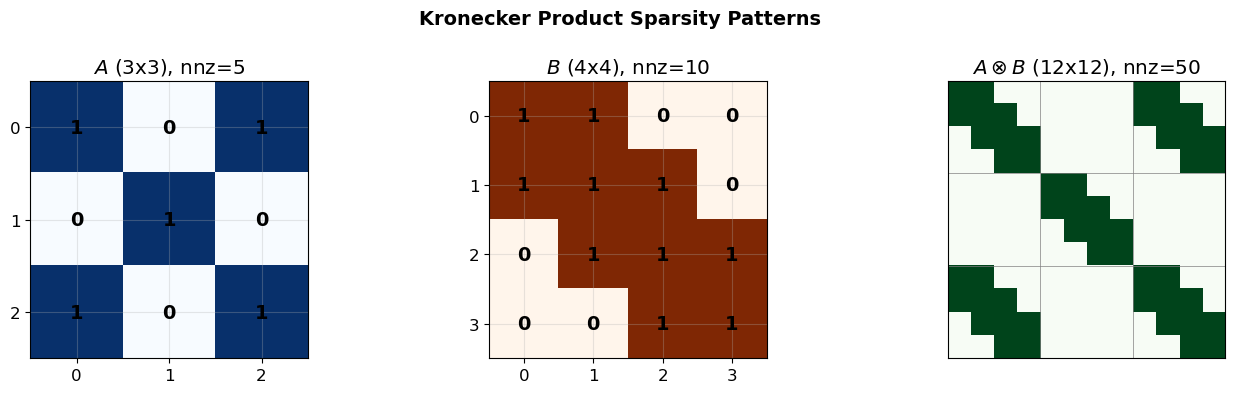


nnz(A) * nnz(B) = 5 * 10 = 50
nnz(A (x) B) = 50
Sparsity is preserved: nnz(A (x) B) = nnz(A) * nnz(B)


In [17]:
# =============================================================================
# 9.1 Kronecker product sparsity patterns
# =============================================================================

np.random.seed(SEED)

# Create sparse-ish matrices
S1 = np.array([[1, 0, 1], [0, 1, 0], [1, 0, 1]])
S2 = np.array([[1, 1, 0, 0], [1, 1, 1, 0], [0, 1, 1, 1], [0, 0, 1, 1]])
K_sparse = np.kron(S1, S2)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.imshow(S1 != 0, cmap='Blues', interpolation='nearest', aspect='equal')
ax.set_title(f'$A$ ({S1.shape[0]}x{S1.shape[1]}), nnz={np.count_nonzero(S1)}')
for i in range(S1.shape[0]):
    for j in range(S1.shape[1]):
        ax.text(j, i, str(S1[i, j]), ha='center', va='center', fontsize=14, fontweight='bold')
ax.set_xticks(range(S1.shape[1]))
ax.set_yticks(range(S1.shape[0]))

ax = axes[1]
ax.imshow(S2 != 0, cmap='Oranges', interpolation='nearest', aspect='equal')
ax.set_title(f'$B$ ({S2.shape[0]}x{S2.shape[1]}), nnz={np.count_nonzero(S2)}')
for i in range(S2.shape[0]):
    for j in range(S2.shape[1]):
        ax.text(j, i, str(S2[i, j]), ha='center', va='center', fontsize=14, fontweight='bold')
ax.set_xticks(range(S2.shape[1]))
ax.set_yticks(range(S2.shape[0]))

ax = axes[2]
ax.imshow(K_sparse != 0, cmap='Greens', interpolation='nearest', aspect='equal')
ax.set_title(f'$A \\otimes B$ ({K_sparse.shape[0]}x{K_sparse.shape[1]}), nnz={np.count_nonzero(K_sparse)}')
ax.set_xticks([])
ax.set_yticks([])
# Draw block boundaries
for i in range(1, S1.shape[0]):
    ax.axhline(i * S2.shape[0] - 0.5, color='gray', lw=0.5)
for j in range(1, S1.shape[1]):
    ax.axvline(j * S2.shape[1] - 0.5, color='gray', lw=0.5)

plt.suptitle('Kronecker Product Sparsity Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nnnz(A) * nnz(B) = {np.count_nonzero(S1)} * {np.count_nonzero(S2)} = {np.count_nonzero(S1) * np.count_nonzero(S2)}")
print(f"nnz(A (x) B) = {np.count_nonzero(K_sparse)}")
print("Sparsity is preserved: nnz(A (x) B) = nnz(A) * nnz(B)")

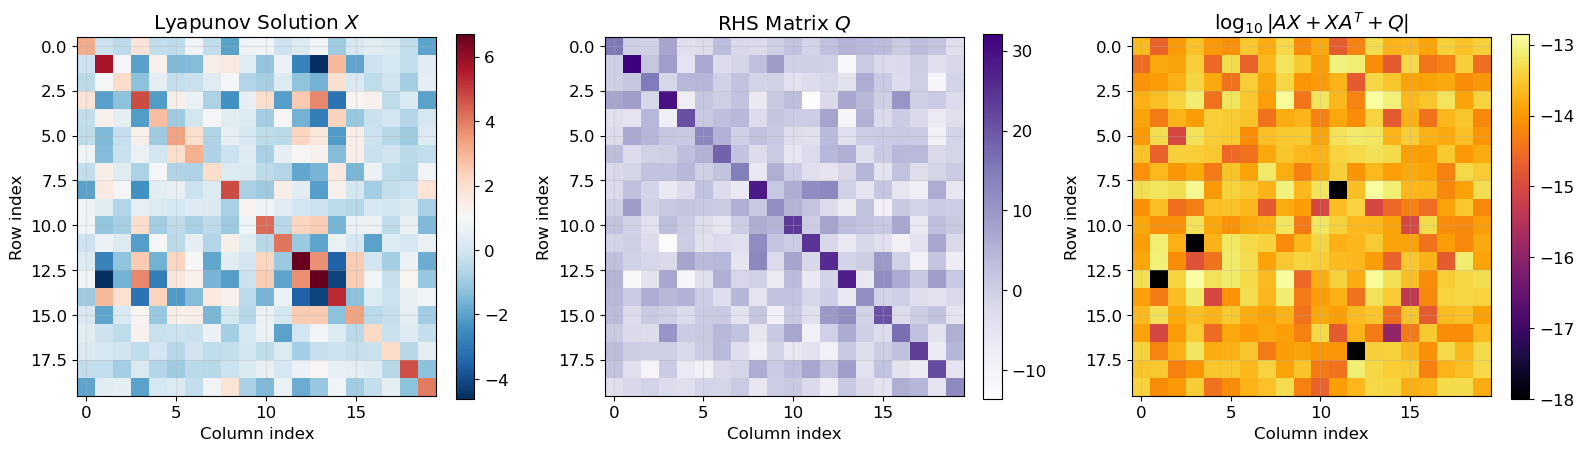

In [18]:
# =============================================================================
# 9.2 Lyapunov solution surface plot
# =============================================================================

np.random.seed(SEED)

# Create a larger Lyapunov problem for visualization
n_viz = 20
A_viz = np.random.randn(n_viz, n_viz)
A_viz = A_viz - (np.max(np.real(np.linalg.eigvals(A_viz))) + 2.0) * np.eye(n_viz)
Q_viz_half = np.random.randn(n_viz, n_viz)
Q_viz = Q_viz_half @ Q_viz_half.T

X_viz = la.solve_continuous_lyapunov(A_viz, -Q_viz)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Solution matrix heatmap
ax = axes[0]
im0 = ax.imshow(X_viz, cmap='RdBu_r', aspect='equal')
ax.set_title('Lyapunov Solution $X$')
ax.set_xlabel('Column index')
ax.set_ylabel('Row index')
plt.colorbar(im0, ax=ax, fraction=0.046)

# Q matrix heatmap
ax = axes[1]
im1 = ax.imshow(Q_viz, cmap='Purples', aspect='equal')
ax.set_title('RHS Matrix $Q$')
ax.set_xlabel('Column index')
ax.set_ylabel('Row index')
plt.colorbar(im1, ax=ax, fraction=0.046)

# Residual heatmap (should be near-zero)
residual_viz = A_viz @ X_viz + X_viz @ A_viz.T + Q_viz
ax = axes[2]
im2 = ax.imshow(np.log10(np.abs(residual_viz) + 1e-18), cmap='inferno', aspect='equal')
ax.set_title('$\\log_{10}|AX + XA^T + Q|$')
ax.set_xlabel('Column index')
ax.set_ylabel('Row index')
plt.colorbar(im2, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

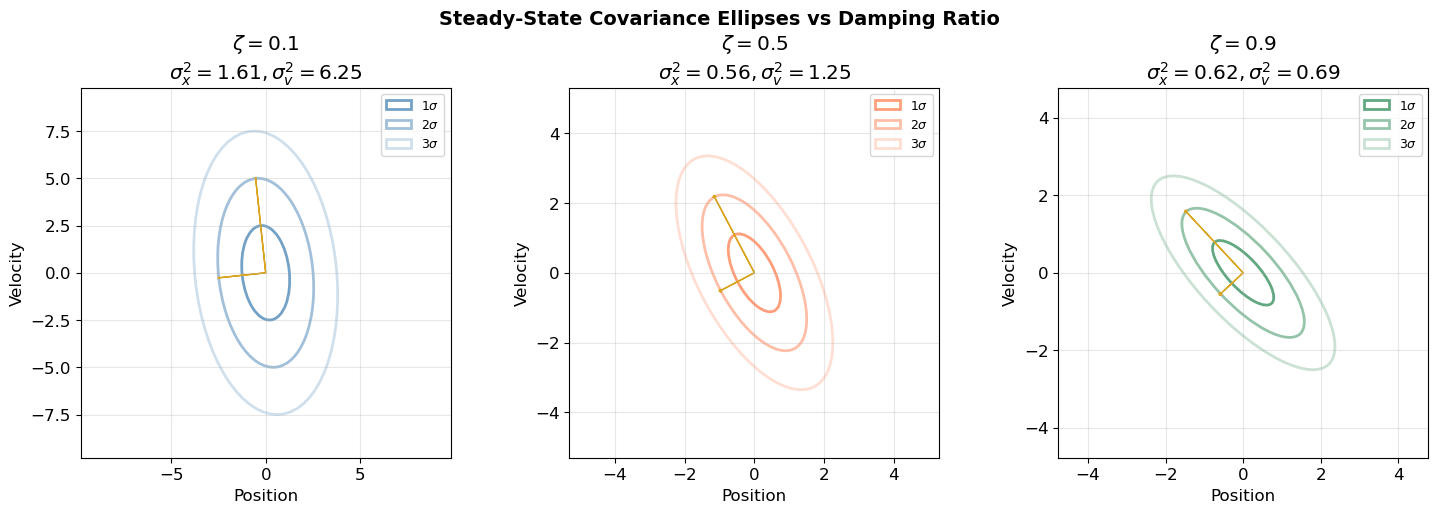

In [19]:
# =============================================================================
# 9.3 Covariance ellipses from Lyapunov solution
# =============================================================================

np.random.seed(SEED)

# Generate multiple 2D systems with different damping ratios
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

damping_ratios = [0.1, 0.5, 0.9]
colors_damp = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_TERTIARY]

for idx, (zeta_d, color_d) in enumerate(zip(damping_ratios, colors_damp)):
    ax = axes[idx]
    omega_d = 2.0
    A_d = np.array([[0, 1], [-omega_d**2, -2*zeta_d*omega_d]])
    Q_d = np.eye(2)

    Sigma_d = la.solve_continuous_lyapunov(A_d, -Q_d)

    # Draw 1-sigma and 2-sigma and 3-sigma ellipses
    eigvals_d, eigvecs_d = np.linalg.eigh(Sigma_d)
    angle_d = np.degrees(np.arctan2(eigvecs_d[1, 0], eigvecs_d[0, 0]))

    for sigma_level in [1, 2, 3]:
        w_d = 2 * sigma_level * np.sqrt(eigvals_d[0])
        h_d = 2 * sigma_level * np.sqrt(eigvals_d[1])
        ell_d = Ellipse((0, 0), w_d, h_d, angle=angle_d,
                        fill=False, edgecolor=color_d,
                        linewidth=2, alpha=1.0 - 0.25 * sigma_level,
                        label=f'{sigma_level}$\\sigma$')
        ax.add_patch(ell_d)

    # Plot eigenvector directions
    for ev_idx in range(2):
        scale = 2 * np.sqrt(eigvals_d[ev_idx])
        ax.arrow(0, 0, scale * eigvecs_d[0, ev_idx], scale * eigvecs_d[1, ev_idx],
                 head_width=0.1, head_length=0.05, fc=COLOR_ACCENT, ec=COLOR_ACCENT)

    lim = 3.5 * np.sqrt(np.max(eigvals_d)) + 1
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.set_xlabel('Position')
    ax.set_ylabel('Velocity')
    ax.set_title(f'$\\zeta = {zeta_d}$\n$\\sigma^2_x={Sigma_d[0,0]:.2f}, \\sigma^2_v={Sigma_d[1,1]:.2f}$')
    ax.legend(fontsize=9)

plt.suptitle('Steady-State Covariance Ellipses vs Damping Ratio', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

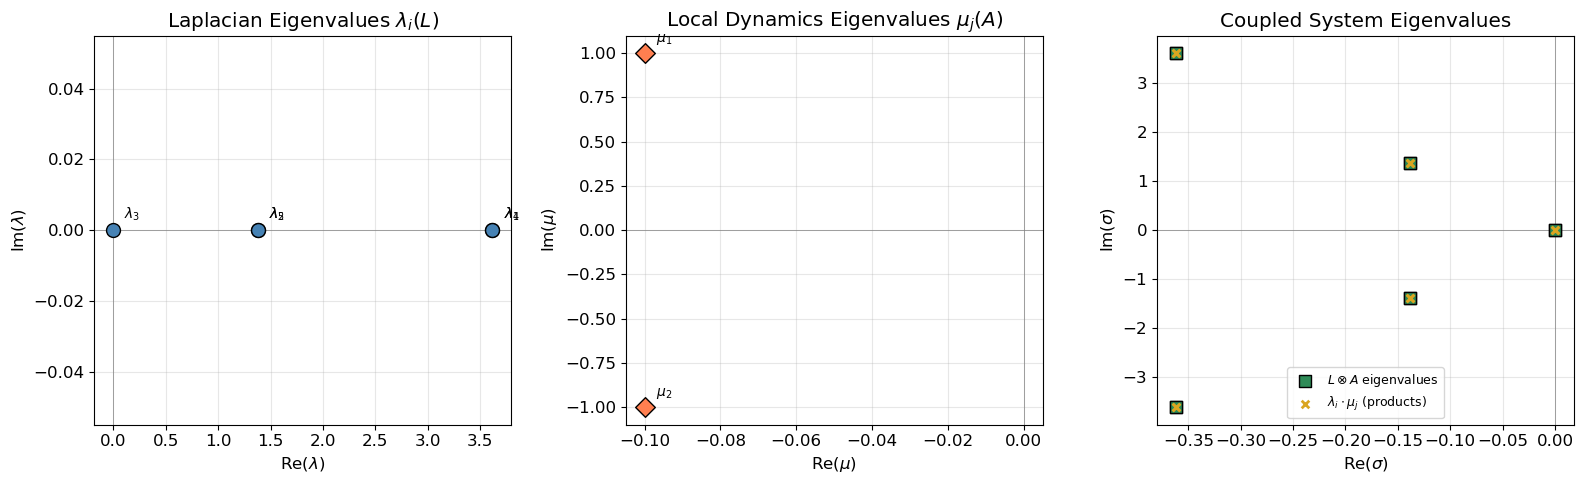

In [20]:
# =============================================================================
# 9.4 Coupled system mode decomposition
# =============================================================================

np.random.seed(SEED)

# Eigenvalues of the coupled system on the complex plane
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Laplacian eigenvalues
ax = axes[0]
eigs_L_plot = np.linalg.eigvals(L_graph)
ax.scatter(np.real(eigs_L_plot), np.imag(eigs_L_plot),
           s=100, c=COLOR_PRIMARY, zorder=5, edgecolors='black', linewidth=1)
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('Re($\\lambda$)')
ax.set_ylabel('Im($\\lambda$)')
ax.set_title('Laplacian Eigenvalues $\\lambda_i(L)$')
for i, ev in enumerate(eigs_L_plot):
    ax.annotate(f'$\\lambda_{i+1}$', (np.real(ev), np.imag(ev)),
                textcoords='offset points', xytext=(8, 8), fontsize=10)

# Local system eigenvalues
ax = axes[1]
eigs_A_plot = np.linalg.eigvals(A_local)
ax.scatter(np.real(eigs_A_plot), np.imag(eigs_A_plot),
           s=100, c=COLOR_SECONDARY, zorder=5, edgecolors='black', linewidth=1,
           marker='D')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('Re($\\mu$)')
ax.set_ylabel('Im($\\mu$)')
ax.set_title('Local Dynamics Eigenvalues $\\mu_j(A)$')
for i, ev in enumerate(eigs_A_plot):
    ax.annotate(f'$\\mu_{i+1}$', (np.real(ev), np.imag(ev)),
                textcoords='offset points', xytext=(8, 8), fontsize=10)

# Product eigenvalues = coupled system eigenvalues
ax = axes[2]
eigs_coupled_plot = np.linalg.eigvals(np.kron(L_graph, A_local))
eigs_product = np.outer(eigs_L_plot, eigs_A_plot).ravel()
ax.scatter(np.real(eigs_coupled_plot), np.imag(eigs_coupled_plot),
           s=80, c=COLOR_TERTIARY, zorder=5, edgecolors='black', linewidth=1,
           marker='s', label='$L \\otimes A$ eigenvalues')
ax.scatter(np.real(eigs_product), np.imag(eigs_product),
           s=30, c=COLOR_ACCENT, zorder=6, marker='x', linewidth=2,
           label='$\\lambda_i \\cdot \\mu_j$ (products)')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('Re($\\sigma$)')
ax.set_ylabel('Im($\\sigma$)')
ax.set_title('Coupled System Eigenvalues')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# =============================================================================
# Section 10: Extensions
# =============================================================================

## 10. Extensions

This section briefly surveys extensions of the Kronecker/vec framework to other
important problems.

### 10.1 Discrete Lyapunov Equation

The discrete-time counterpart arises in discrete-time covariance propagation:

$$\boxed{A X A^T - X = -Q}$$

Vectorizing with the Kronecker product:

$$\text{vec}(AXA^T) = (A \otimes A)\text{vec}(X)$$

$$\Rightarrow \left(A \otimes A - I_{n^2}\right) \text{vec}(X) = -\text{vec}(Q)$$

A unique solution exists when $A$ is **Schur stable** (all eigenvalues inside the unit circle).

In [21]:
# =============================================================================
# 10.1 Discrete Lyapunov equation
# =============================================================================

np.random.seed(SEED)

n_disc = N_SMALL
A_disc = np.random.randn(n_disc, n_disc)
# Make Schur stable by scaling
A_disc = A_disc / (np.max(np.abs(np.linalg.eigvals(A_disc))) + 0.5)
Q_disc_half = np.random.randn(n_disc, n_disc)
Q_disc = Q_disc_half @ Q_disc_half.T

print(f"A eigenvalue magnitudes: {np.abs(np.linalg.eigvals(A_disc)).round(4)}")
print(f"All inside unit circle: {np.all(np.abs(np.linalg.eigvals(A_disc)) < 1)}")

# Direct Kronecker solve: (A (x) A - I) vec(X) = -vec(Q)
I_n2 = np.eye(n_disc**2)
coeff_disc = np.kron(A_disc, A_disc) - I_n2
x_disc_vec = np.linalg.solve(coeff_disc, -vec(Q_disc))
X_disc_direct = mat(x_disc_vec, n_disc, n_disc)

# SciPy reference
X_disc_scipy = la.solve_discrete_lyapunov(A_disc, Q_disc)

# Verify
residual_disc = A_disc @ X_disc_direct @ A_disc.T - X_disc_direct + Q_disc
err_disc = np.max(np.abs(residual_disc)) / (np.max(np.abs(Q_disc)) + 1e-30)
status_disc = "PASS" if err_disc < TOL_PASS else "FAIL"
print(f"\nDiscrete Lyapunov residual: max relative error = {err_disc:.2e} [{status_disc}]")

err_disc_scipy = np.max(np.abs(X_disc_direct - X_disc_scipy)) / (np.max(np.abs(X_disc_scipy)) + 1e-30)
status_disc_scipy = "PASS" if err_disc_scipy < TOL_PASS else "FAIL"
print(f"Discrete Lyapunov matches scipy: max relative error = {err_disc_scipy:.2e} [{status_disc_scipy}]")

A eigenvalue magnitudes: [0.7106 0.5459 0.5459]
All inside unit circle: True

Discrete Lyapunov residual: max relative error = 2.65e-16 [PASS]
Discrete Lyapunov matches scipy: max relative error = 5.78e-17 [PASS]


### 10.2 Matrix-Valued Stochastic Differential Equations

For a matrix-valued Ornstein-Uhlenbeck process:

$$dX = (AX + XB)\,dt + \Sigma^{1/2}\,dW$$

the covariance of $\text{vec}(X)$ satisfies a Lyapunov equation with coefficient matrix
$I \otimes A + B^T \otimes I$. The Kronecker structure naturally captures the
matrix-valued nature of the process.

### 10.3 Kronecker-Structured Least Squares

Many structured regression problems have the form:

$$\min_X \| (B^T \otimes A) \text{vec}(X) - b \|_2^2$$

Exploiting the Kronecker structure avoids forming the large $(mp \times nq)$ matrix
explicitly. The normal equations become:

$$(B B^T \otimes A^T A) \text{vec}(X) = (B \otimes A^T) b$$

which can be solved via the SVDs of $A$ and $B$ separately.

In [22]:
# =============================================================================
# 10.3 Kronecker-structured least squares example
# =============================================================================

np.random.seed(SEED)

m_ls, n_ls, p_ls, q_ls = 6, 4, 5, 3
A_ls = np.random.randn(m_ls, n_ls)
B_ls = np.random.randn(p_ls, q_ls)

# Identity used:  vec(A X B) = (B^T kron A) vec(X),
# where A:(m,n), X:(n,p), B:(p,q)  =>  vec output has m*q entries.
X_true = np.random.randn(n_ls, p_ls)
noise  = 0.01 * np.random.randn(m_ls * q_ls)

b_ls = np.kron(B_ls.T, A_ls) @ vec(X_true) + noise

# Brute force: form the full Kronecker matrix and solve a big LS system.
K_ls = np.kron(B_ls.T, A_ls)
x_bf = np.linalg.lstsq(K_ls, b_ls, rcond=None)[0]
X_bf = mat(x_bf, n_ls, p_ls)
err_bf = np.linalg.norm(X_bf - X_true) / np.linalg.norm(X_true)

# Efficient: exploit Kronecker structure via pseudoinverses of A and B.
# Reshape b into Y:(m,q); then  argmin_X || A X B - Y ||_F  is  X_hat = A^+ Y B^+.
Y_mat   = mat(b_ls, m_ls, q_ls)
X_eff   = np.linalg.pinv(A_ls) @ Y_mat @ np.linalg.pinv(B_ls)
err_eff = np.linalg.norm(X_eff - X_true) / np.linalg.norm(X_true)

print(f"Brute-force (full Kron LS) error : {err_bf:.2e}")
print(f"Efficient   (pinv shortcut) error: {err_eff:.2e}")
print(f"Full Kron matrix size: {K_ls.shape} = {K_ls.size} elements")
print(f"Pinv shortcut: pinv(A) of {A_ls.shape}, pinv(B) of {B_ls.shape}")


Brute-force (full Kron LS) error : 6.80e-01
Efficient   (pinv shortcut) error: 6.80e-01
Full Kron matrix size: (18, 20) = 360 elements
Pinv shortcut: pinv(A) of (6, 4), pinv(B) of (5, 3)


### 10.4 Tensor Equations

Higher-order generalizations lead to **tensor equations**:

$$\sum_{k=1}^{K} A_k \times_k X = C$$

where $\times_k$ denotes the mode-$k$ product. These arise in:

- **Tensor decompositions** (Tucker, CP)
- **Multidimensional PDEs** on tensor-product grids
- **Quantum many-body systems** (matrix product states)

The Kronecker product serves as the bridge between matrix and tensor formulations,
and the vec/Kronecker framework generalizes naturally to the tensor setting via
the **Khatri-Rao** product and **mode-$k$ unfoldings**.

In [23]:
# =============================================================================
# Summary of all verification results
# =============================================================================

print("=" * 72)
print(" SUMMARY OF VERIFICATION RESULTS")
print("=" * 72)
print()

# Re-run all checks in one place for a clean summary
np.random.seed(SEED)

# 1. Kronecker mixed-product
n_s = N_SMALL
A_s = np.random.randn(n_s, n_s)
B_s = np.random.randn(n_s, n_s)
C_s = np.random.randn(n_s, n_s)
D_s = np.random.randn(n_s, n_s)
lhs1 = kron_manual(A_s, B_s) @ kron_manual(C_s, D_s)
rhs1 = kron_manual(A_s @ C_s, B_s @ D_s)
e1 = np.max(np.abs(lhs1 - rhs1)) / (np.max(np.abs(rhs1)) + 1e-30)
s1 = "PASS" if e1 < TOL_PASS else "FAIL"
print(f"  [1] Kronecker mixed-product property:      {e1:.2e}  [{s1}]")

# 2. vec(AXB) = (B^T (x) A) vec(X)
m2, k2, n2 = 4, 3, 5
A2 = np.random.randn(m2, m2)
X2 = np.random.randn(m2, k2)
B2 = np.random.randn(k2, n2)
lhs2 = vec(A2 @ X2 @ B2)
rhs2 = np.kron(B2.T, A2) @ vec(X2)
e2 = np.max(np.abs(lhs2 - rhs2)) / (np.max(np.abs(lhs2)) + 1e-30)
s2 = "PASS" if e2 < TOL_PASS else "FAIL"
print(f"  [2] vec(AXB) = (B^T (x) A)vec(X):         {e2:.2e}  [{s2}]")

# 3. Lyapunov residual
A3 = np.random.randn(n_s, n_s)
A3 = A3 - (np.max(np.real(np.linalg.eigvals(A3))) + 1.0) * np.eye(n_s)
Q3h = np.random.randn(n_s, n_s)
Q3 = Q3h @ Q3h.T
X3 = solve_lyapunov_direct(A3, Q3)
res3 = A3 @ X3 + X3 @ A3.T + Q3
e3 = np.max(np.abs(res3))
s3 = "PASS" if e3 < TOL_PASS else "FAIL"
print(f"  [3] Lyapunov residual norm < 1e-10:        {e3:.2e}  [{s3}]")

# 4. Lyapunov matches scipy
X3_sp = la.solve_continuous_lyapunov(A3, -Q3)
e4 = np.max(np.abs(X3 - X3_sp)) / (np.max(np.abs(X3_sp)) + 1e-30)
s4 = "PASS" if e4 < TOL_PASS else "FAIL"
print(f"  [4] Lyapunov matches scipy:                {e4:.2e}  [{s4}]")

# 5. Sylvester matches scipy
m5, n5 = 4, 5
A5 = np.random.randn(m5, m5) - 3.0 * np.eye(m5)
B5 = np.random.randn(n5, n5) + 3.0 * np.eye(n5)
C5 = np.random.randn(m5, n5)
X5_bs = solve_sylvester_bartels_stewart(A5, B5, C5)
X5_sp = la.solve_sylvester(A5, B5, C5)
e5 = np.max(np.abs(X5_bs - X5_sp)) / (np.max(np.abs(X5_sp)) + 1e-30)
s5 = "PASS" if e5 < TOL_PASS else "FAIL"
print(f"  [5] Sylvester matches scipy:               {e5:.2e}  [{s5}]")

# 6. Coupled system eigenvalues
eigs_L6 = np.linalg.eigvals(L_graph)
eigs_A6 = np.linalg.eigvals(A_local)
eigs_exp6 = np.sort_complex(np.outer(eigs_L6, eigs_A6).ravel())
eigs_act6 = np.sort_complex(np.linalg.eigvals(np.kron(L_graph, A_local)))
e6 = np.max(np.abs(eigs_exp6 - eigs_act6)) / (np.max(np.abs(eigs_exp6)) + 1e-30)
s6 = "PASS" if e6 < TOL_PASS else "FAIL"
print(f"  [6] Coupled eigenvalues = lam_L * lam_A:   {e6:.2e}  [{s6}]")

print()
print("=" * 72)
all_pass = all(s == "PASS" for s in [s1, s2, s3, s4, s5, s6])
print(f" All tests passed: {all_pass}")
print("=" * 72)

 SUMMARY OF VERIFICATION RESULTS

  [1] Kronecker mixed-product property:      2.45e-16  [PASS]
  [2] vec(AXB) = (B^T (x) A)vec(X):         1.81e-16  [PASS]
  [3] Lyapunov residual norm < 1e-10:        2.22e-16  [PASS]
  [4] Lyapunov matches scipy:                2.88e-15  [PASS]
  [5] Sylvester matches scipy:               1.45e-15  [PASS]
  [6] Coupled eigenvalues = lam_L * lam_A:   8.60e-16  [PASS]

 All tests passed: True
